In [8]:
! pip install -U scikit-learn

In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import poisson
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np

#pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

pd.reset_option('display.max_rows')
#pd.reset_option('display.max_columns')

In [2]:
filePath = 'premier_league_clean.csv'
df = pd.read_csv(filePath)
df

,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR,IWH,IWD,IWA,WHH,WHD,WHA,B365H,B365D,B365A,B365>2.5,B365<2.5,Date,Season,Year,Month,DayOfWeek,TotalGoals,GoalsOver2_5,HomeTeam_mean_FTHG,AwayTeam_mean_FTAG,HomeTeam,AwayTeam,HomeTeam_Arsenal,HomeTeam_Aston Villa,HomeTeam_Birmingham,HomeTeam_Blackburn,HomeTeam_Blackpool,HomeTeam_Bolton,HomeTeam_Bournemouth,HomeTeam_Brentford,HomeTeam_Brighton,HomeTeam_Burnley,HomeTeam_Cardiff,HomeTeam_Charlton,HomeTeam_Chelsea,HomeTeam_Crystal Palace,HomeTeam_Derby,HomeTeam_Everton,HomeTeam_Fulham,HomeTeam_Huddersfield,HomeTeam_Hull,HomeTeam_Leeds,HomeTeam_Leicester,HomeTeam_Liverpool,HomeTeam_Luton,HomeTeam_Man City,HomeTeam_Man United,HomeTeam_Middlesbrough,HomeTeam_Newcastle,HomeTeam_Norwich,HomeTeam_Nott'm Forest,HomeTeam_Portsmouth,HomeTeam_QPR,HomeTeam_Reading,HomeTeam_Sheffield United,HomeTeam_Southampton,HomeTeam_Stoke,HomeTeam_Sunderland,HomeTeam_Swansea,HomeTeam_Tottenham,HomeTeam_Watford,HomeTeam_West Brom,HomeTeam_West Ham,HomeTeam_Wigan,HomeTeam_Wolves,AwayTeam_Arsenal,AwayTeam_Aston Villa,AwayTeam_Birmingham,AwayTeam_Blackburn,AwayTeam_Blackpool,AwayTeam_Bolton,AwayTeam_Bournemouth,AwayTeam_Brentford,AwayTeam_Brighton,AwayTeam_Burnley,AwayTeam_Cardiff,AwayTeam_Charlton,AwayTeam_Chelsea,AwayTeam_Crystal Palace,AwayTeam_Derby,AwayTeam_Everton,AwayTeam_Fulham,AwayTeam_Huddersfield,AwayTeam_Hull,AwayTeam_Leeds,AwayTeam_Leicester,AwayTeam_Liverpool,AwayTeam_Luton,AwayTeam_Man City,AwayTeam_Man United,AwayTeam_Middlesbrough,AwayTeam_Newcastle,AwayTeam_Norwich,AwayTeam_Nott'm Forest,AwayTeam_Portsmouth,AwayTeam_QPR,AwayTeam_Reading,AwayTeam_Sheffield United,AwayTeam_Southampton,AwayTeam_Stoke,AwayTeam_Sunderland,AwayTeam_Swansea,AwayTeam_Tottenham,AwayTeam_Watford,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves,has_ou_odds
0,1.0,1.0,D,0.0,0.0,D,G Poll,19.0,5.0,11.0,3.0,18.0,1.0,10.0,19.0,1.0,2.0,0.0,0.0,1.30,4.40,8.50,1.28,4.50,8.00,1.28,4.50,13.00,1.867394,2.013934,2006-08-19,2006-07,2006,8,5,2.0,0,2.120907,1.127907,Arsenal,Aston Villa,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2.0,0.0,H,2.0,0.0,H,P Dowd,8.0,9.0,6.0,6.0,6.0,3.0,19.0,22.0,0.0,1.0,0.0,0.0,2.50,3.10,2.60,2.60,3.10,2.40,2.62,3.20,2.60,1.867394,2.013934,2006-08-19,2006-07,2006,8,5,2.0,0,1.359551,1.449749,Bolton,Tottenham,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,2.0,1.0,H,1.0,0.0,H,P Walton,6.0,12.0,2.0,8.0,0.0,6.0,12.0,13.0,2.0,2.0,0.0,0.0,1.70,3.40,4.30,1.57,3.30,5.50,1.66,3.40,5.50,1.867394,2.013934,2006-08-19,2006-07,2006,8,5,3.0,1,1.537500,0.894737,Everton,Watford,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,2.0,1.0,H,1.0,0.0,H,M Atkinson,9.0,14.0,8.0,9.0,4.0,11.0,17.0,20.0,1.0,2.0,0.0,0.0,1.70,3.40,4.30,1.72,3.20,4.33,1.72,3.50,4.75,1.867394,2.013934,2006-08-19,2006-07,2006,8,5,3.0,1,1.476454,0.972603,Newcastle,Wigan,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,3.0,0.0,H,1.0,0.0,H,A Wiley,21.0,9.0,16.0,7.0,6.0,2.0,20.0,17.0,2.0,1.0,0.0,2.0,2.50,3.10,2.60,2.20,3.10,2.87,2.30,3.10,3.10,1.867394,2.013934,2006-08-19,2006-07,2006,8,5,3.0,1,1.278689,1.061453,Portsmouth,Blackburn,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

Home Goals MAE: 0.9794792973651192
Home Goals RMSE: 1.228174145426087
Away Goals MAE: 0.8931179422835633
Away Goals RMSE: 1.1223772438626765


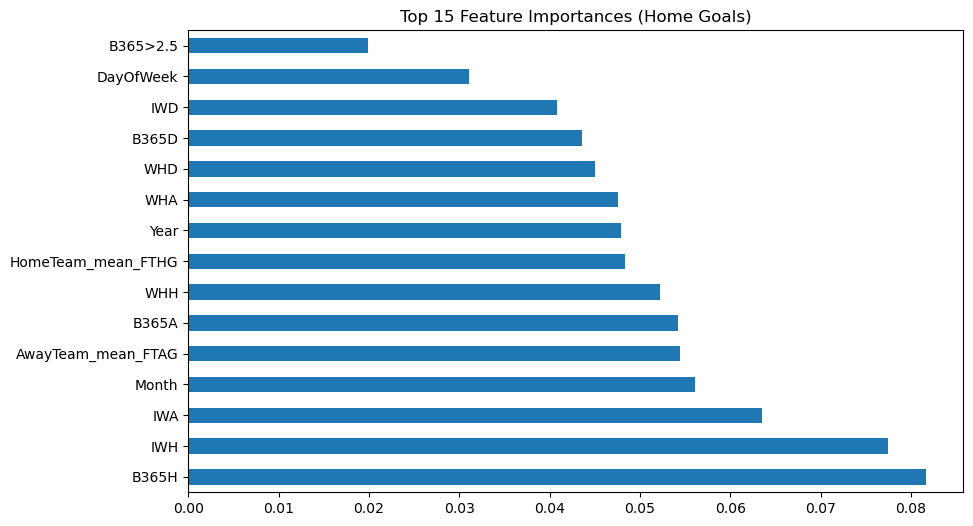

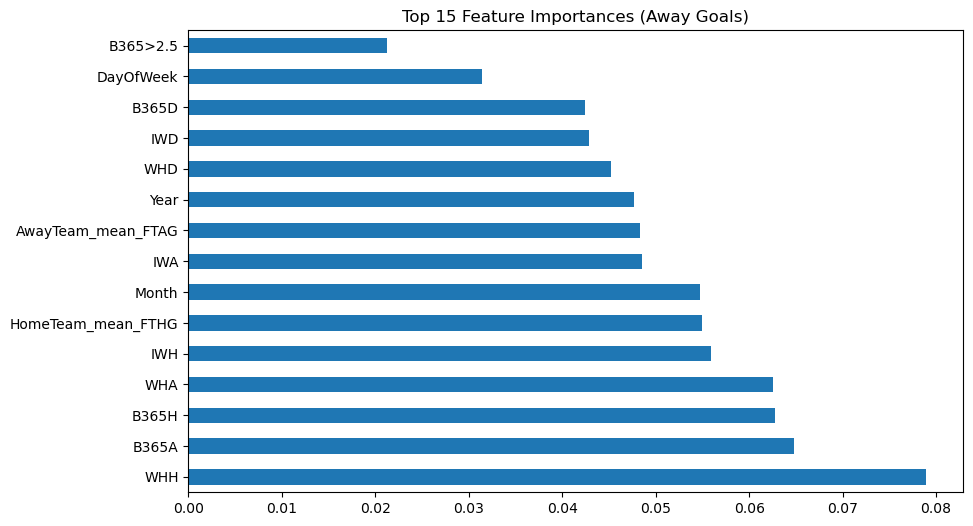

In [3]:
cols_to_drop = [
    'GoalsOver2_5', 'TotalGoals', 'FTHG', 'FTAG',
    'HTHG', 'HTAG',
    'HS', 'AS', 'HST', 'AST',  
    'HC', 'AC',               
    'HF', 'AF',               
    'HY', 'AY',               
    'HR', 'AR',               
    'FTR_H', 'FTR_A', 'FTR_D',
    'HTR_H', 'HTR_A', 'HTR_D',
    'FTR', 'HTR',
    'HomeTeam', 'AwayTeam',
    'Date', 'Referee',
    'Season',
    'HomeGoalDiff', 'AwayGoalDiff',
    'HomePts', 'AwayPts'    
]

X = df.drop(columns=cols_to_drop, errors='ignore')
y = df[['FTHG', 'FTAG']] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_home = RandomForestRegressor(n_estimators=100, random_state=42)
rf_home.fit(X_train, y_train['FTHG'])
y_pred_home = rf_home.predict(X_test)
print("Home Goals MAE:", mean_absolute_error(y_test['FTHG'], y_pred_home))
print("Home Goals RMSE:", np.sqrt(mean_squared_error(y_test['FTHG'], y_pred_home)))

rf_away = RandomForestRegressor(n_estimators=100, random_state=42)
rf_away.fit(X_train, y_train['FTAG'])
y_pred_away = rf_away.predict(X_test)
print("Away Goals MAE:", mean_absolute_error(y_test['FTAG'], y_pred_away))
print("Away Goals RMSE:", np.sqrt(mean_squared_error(y_test['FTAG'], y_pred_away)))

feat_importances_home = pd.Series(rf_home.feature_importances_, index=X.columns)
feat_importances_away = pd.Series(rf_away.feature_importances_, index=X.columns)

plt.figure(figsize=(10, 6))
feat_importances_home.nlargest(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (Home Goals)')
plt.show()

plt.figure(figsize=(10, 6))
feat_importances_away.nlargest(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (Away Goals)')
plt.show()

In [5]:
league_avg_home = y_train['FTHG'].mean()
league_avg_away = y_train['FTAG'].mean()

In [6]:
y_pred_home_naive = np.full(shape=len(y_test), fill_value=league_avg_home)
y_pred_away_naive = np.full(shape=len(y_test), fill_value=league_avg_away)

In [11]:
mae_home_naive = mean_absolute_error(y_test['FTHG'], y_pred_home_naive)
rmse_home_naive = mean_squared_error(y_test['FTHG'], y_pred_home_naive)

mae_away_naive = mean_absolute_error(y_test['FTAG'], y_pred_away_naive)
rmse_away_naive = mean_squared_error(y_test['FTAG'], y_pred_away_naive)

print("Naive Baseline - Home Goals MAE:", mae_home_naive)
print("Naive Baseline - Home Goals RMSE:", rmse_home_naive)
print("Naive Baseline - Away Goals MAE:", mae_away_naive)
print("Naive Baseline - Away Goals RMSE:", rmse_away_naive)

Naive Baseline - Home Goals MAE: 1.0606633790713922
Naive Baseline - Home Goals RMSE: 1.7171701571557516
Naive Baseline - Away Goals MAE: 0.9089054922689527
Naive Baseline - Away Goals RMSE: 1.3263902142865214


MultiOutput Random Forest:
Home Goals MAE: 0.9794792973651192
Home Goals RMSE: 1.228174145426087
Away Goals MAE: 0.8931179422835633
Away Goals RMSE: 1.1223772438626765


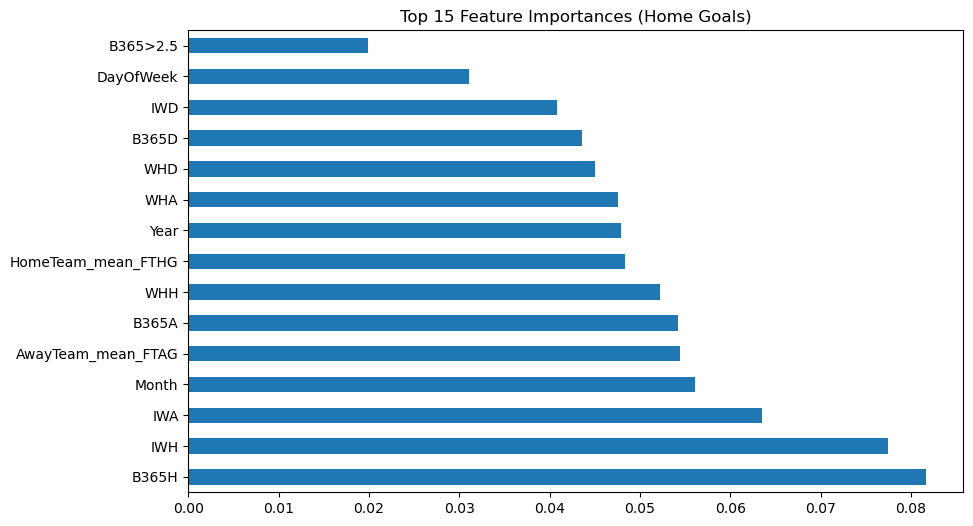

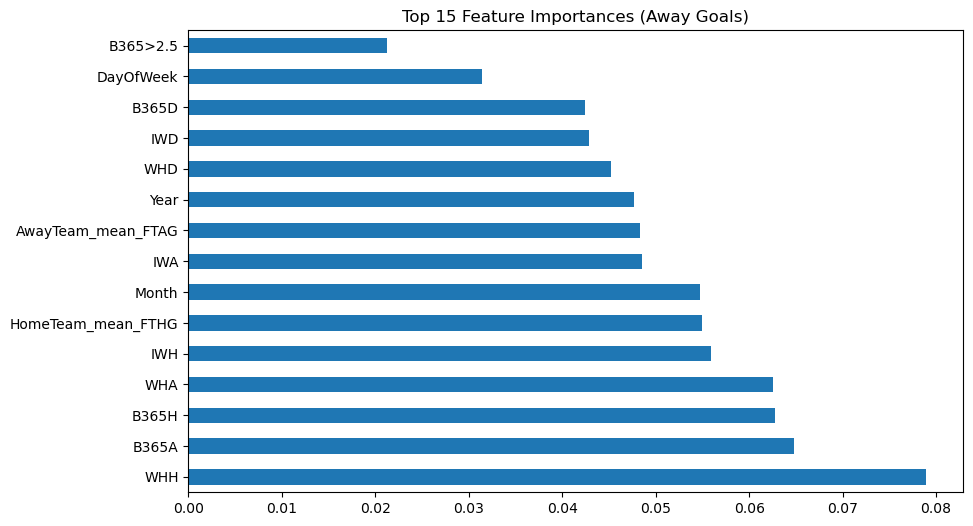

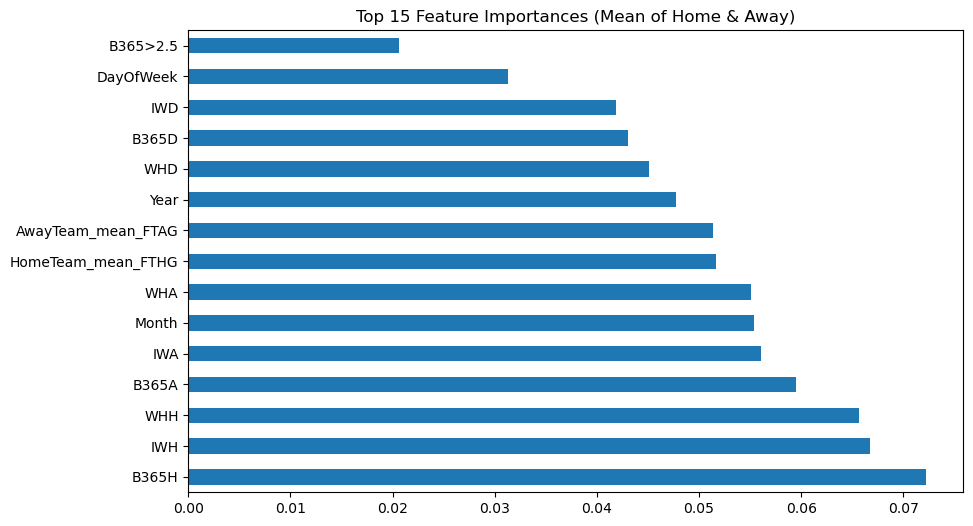

In [13]:
cols_to_drop = [
    'GoalsOver2_5', 'TotalGoals', 'FTHG', 'FTAG',
    'HTHG', 'HTAG',
    'HS', 'AS', 'HST', 'AST',  
    'HC', 'AC',               
    'HF', 'AF',               
    'HY', 'AY',               
    'HR', 'AR',               
    'FTR_H', 'FTR_A', 'FTR_D',
    'HTR_H', 'HTR_A', 'HTR_D',
    'FTR', 'HTR',
    'HomeTeam', 'AwayTeam',
    'Date', 'Referee',
    'Season',
    'HomeGoalDiff', 'AwayGoalDiff',
    'HomePts', 'AwayPts'    
]

X = df.drop(columns=cols_to_drop, errors='ignore')
y = df[['FTHG', 'FTAG']] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

multi_rf = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
multi_rf.fit(X_train, y_train)
y_pred_multi = multi_rf.predict(X_test)

mae_home = mean_absolute_error(y_test['FTHG'], y_pred_multi[:, 0])
rmse_home = np.sqrt(mean_squared_error(y_test['FTHG'], y_pred_multi[:, 0]))
mae_away = mean_absolute_error(y_test['FTAG'], y_pred_multi[:, 1])
rmse_away = np.sqrt(mean_squared_error(y_test['FTAG'], y_pred_multi[:, 1]))

print("MultiOutput Random Forest:")
print("Home Goals MAE:", mae_home)
print("Home Goals RMSE:", rmse_home)
print("Away Goals MAE:", mae_away)
print("Away Goals RMSE:", rmse_away)

feat_importances_home = multi_rf.estimators_[0].feature_importances_
feat_importances_away = multi_rf.estimators_[1].feature_importances_
feat_importances_mean = (feat_importances_home + feat_importances_away) / 2

plt.figure(figsize=(10, 6))
pd.Series(feat_importances_home, index=X.columns).nlargest(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (Home Goals)')
plt.show()

plt.figure(figsize=(10, 6))
pd.Series(feat_importances_away, index=X.columns).nlargest(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (Away Goals)')
plt.show()

plt.figure(figsize=(10, 6))
pd.Series(feat_importances_mean, index=X.columns).nlargest(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (Mean of Home & Away)')
plt.show()

MultiOutput XGBoost Results:
Home Goals MAE: 1.0112534591991225
Home Goals RMSE: 1.275935144049399
Away Goals MAE: 0.9181231129488007
Away Goals RMSE: 1.1694305398520954


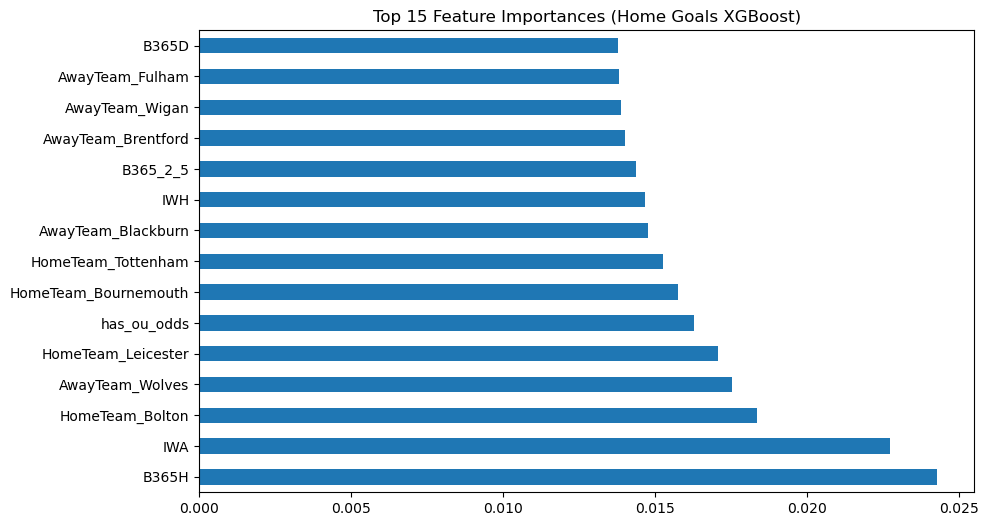

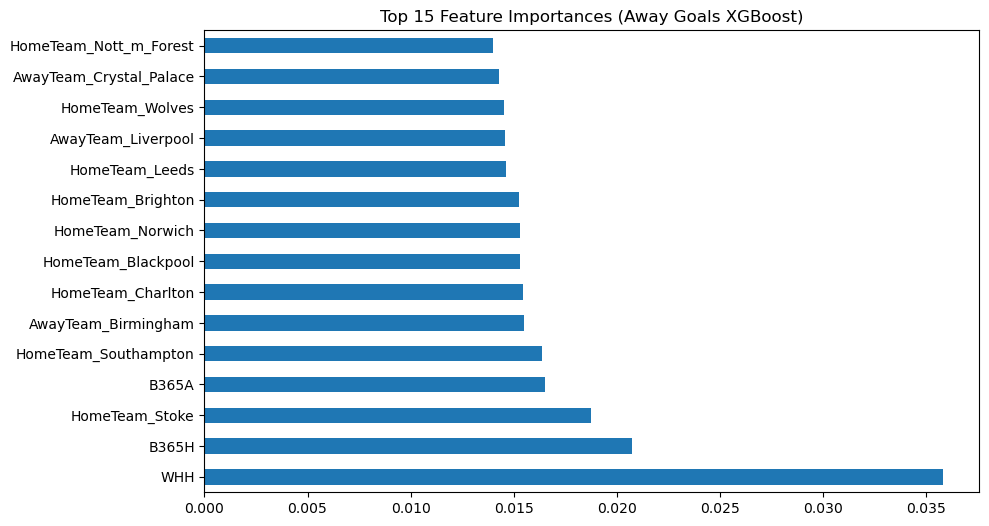

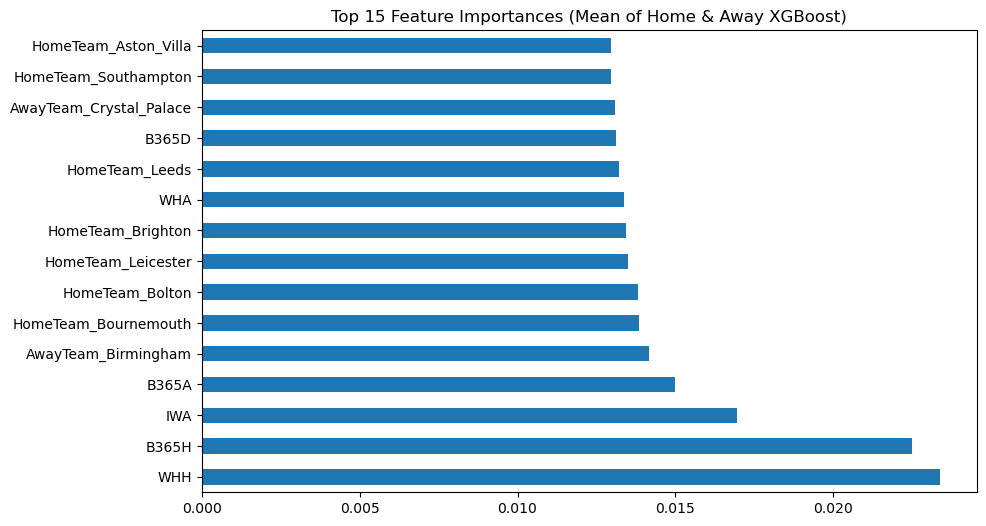

In [18]:
cols_to_drop = [
    'GoalsOver2_5', 'TotalGoals', 'FTHG', 'FTAG',
    'HTHG', 'HTAG',
    'HS', 'AS', 'HST', 'AST',  
    'HC', 'AC',               
    'HF', 'AF',               
    'HY', 'AY',               
    'HR', 'AR',               
    'FTR_H', 'FTR_A', 'FTR_D',
    'HTR_H', 'HTR_A', 'HTR_D',
    'FTR', 'HTR',
    'HomeTeam', 'AwayTeam',
    'Date', 'Referee',
    'Season',
    'HomeGoalDiff', 'AwayGoalDiff',
    'HomePts', 'AwayPts'    
]

# df = pd.read_csv('your_clean_data.csv') # Uncomment and load your data here

X = df.drop(columns=cols_to_drop, errors='ignore')
X.columns = X.columns.str.replace(r"[^\w]", "_", regex=True)
y = df[['FTHG', 'FTAG']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

multi_xgb = MultiOutputRegressor(
    xgb.XGBRegressor(n_estimators=100, random_state=42, tree_method='hist')
)
multi_xgb.fit(X_train.values, y_train.values)
y_pred_multi = multi_xgb.predict(X_test.values)

mae_home = mean_absolute_error(y_test['FTHG'], y_pred_multi[:, 0])
rmse_home = np.sqrt(mean_squared_error(y_test['FTHG'], y_pred_multi[:, 0]))
mae_away = mean_absolute_error(y_test['FTAG'], y_pred_multi[:, 1])
rmse_away = np.sqrt(mean_squared_error(y_test['FTAG'], y_pred_multi[:, 1]))

print("MultiOutput XGBoost Results:")
print("Home Goals MAE:", mae_home)
print("Home Goals RMSE:", rmse_home)
print("Away Goals MAE:", mae_away)
print("Away Goals RMSE:", rmse_away)

feat_importances_home = multi_xgb.estimators_[0].feature_importances_
feat_importances_away = multi_xgb.estimators_[1].feature_importances_
feat_importances_mean = (feat_importances_home + feat_importances_away) / 2

plt.figure(figsize=(10, 6))
pd.Series(feat_importances_home, index=X.columns).nlargest(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (Home Goals XGBoost)')
plt.show()

plt.figure(figsize=(10, 6))
pd.Series(feat_importances_away, index=X.columns).nlargest(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (Away Goals XGBoost)')
plt.show()

plt.figure(figsize=(10, 6))
pd.Series(feat_importances_mean, index=X.columns).nlargest(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (Mean of Home & Away XGBoost)')
plt.show()

In [20]:
mu_home = y_pred_multi[:, 0]
mu_away = y_pred_multi[:, 1]
mu_total = mu_home + mu_away

# 2. Calculate Poisson probability for under/over 2.5 goals
# Under 2.5 = sum of probabilities for 0, 1, or 2 total goals
prob_under_2_5 = (
    poisson.pmf(0, mu_total) +
    poisson.pmf(1, mu_total) +
    poisson.pmf(2, mu_total)
)
# Over 2.5 = 1 - prob_under_2_5
prob_over_2_5 = 1 - prob_under_2_5

# 3. Make a DataFrame for inspection
poisson_results = pd.DataFrame({
    'mu_home': mu_home,
    'mu_away': mu_away,
    'mu_total': mu_total,
    'prob_under_2_5': prob_under_2_5,
    'prob_over_2_5': prob_over_2_5,
})

print(poisson_results.head())

# 4. Example: Classify matches as "over 2.5" if probability > 0.5
poisson_results['predicted_over_2_5'] = (poisson_results['prob_over_2_5'] > 0.5).astype(int)

# 5. (Optional) Compare to actual outcome if you have true total goals
y_test_total_goals = y_test['FTHG'] + y_test['FTAG']
poisson_results['actual_over_2_5'] = (y_test_total_goals > 2.5).astype(int)

# 6. (Optional) Evaluate performance
accuracy = (poisson_results['predicted_over_2_5'] == poisson_results['actual_over_2_5']).mean()
print(f"Classification accuracy for over/under 2.5: {accuracy:.3f}")

    mu_home   mu_away  mu_total  prob_under_2_5  prob_over_2_5
0  1.712946  0.852453  2.565399        0.527150       0.472850
1  1.372685  1.849132  3.221817        0.375369       0.624631
2  2.461425  1.119096  3.580521        0.306211       0.693789
3  0.613692  0.156480  0.770172        0.956770       0.043230
4  2.160800  0.866842  3.027642        0.417026       0.582974
Classification accuracy for over/under 2.5: 0.107


In [21]:
print(poisson_results['actual_over_2_5'].value_counts(normalize=True))

actual_over_2_5
1.0    0.526627
0.0    0.473373
Name: proportion, dtype: float64


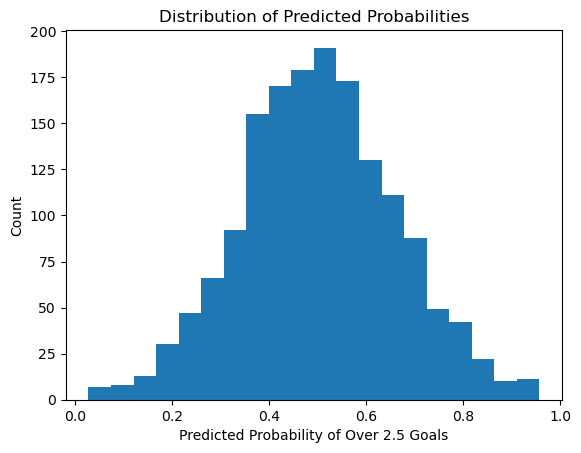

In [22]:
plt.hist(poisson_results['prob_over_2_5'], bins=20)
plt.xlabel('Predicted Probability of Over 2.5 Goals')
plt.ylabel('Count')
plt.title('Distribution of Predicted Probabilities')
plt.show()

In [23]:
for thresh in np.arange(0.3, 0.8, 0.05):
    pred = (poisson_results['prob_over_2_5'] > thresh).astype(int)
    acc = (pred == poisson_results['actual_over_2_5']).mean()
    print(f"Threshold {thresh:.2f}: Accuracy {acc:.3f}")

Threshold 0.30: Accuracy 0.112
Threshold 0.35: Accuracy 0.110
Threshold 0.40: Accuracy 0.109
Threshold 0.45: Accuracy 0.108
Threshold 0.50: Accuracy 0.107
Threshold 0.55: Accuracy 0.110
Threshold 0.60: Accuracy 0.104
Threshold 0.65: Accuracy 0.102
Threshold 0.70: Accuracy 0.101
Threshold 0.75: Accuracy 0.102


Accuracy: 0.536
ROC-AUC: 0.555
Brier score: 0.253


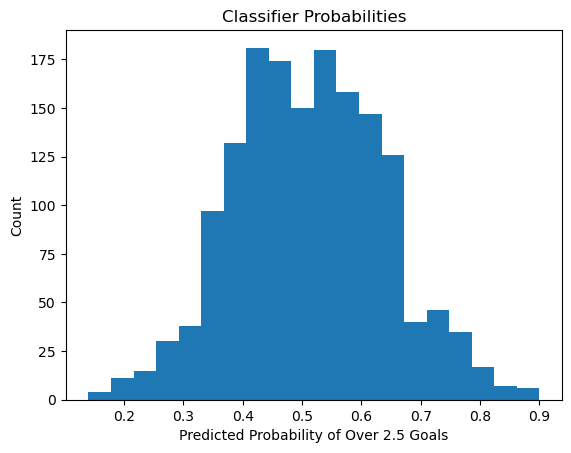

In [33]:
df['over_2_5'] = (df['FTHG'] + df['FTAG'] > 2.5).astype(int)

cols_to_drop = [
    'GoalsOver2_5', 'TotalGoals', 'FTHG', 'FTAG',
    'HTHG', 'HTAG', 'HS', 'AS', 'HST', 'AST',  
    'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR',
    'FTR_H', 'FTR_A', 'FTR_D', 'HTR_H', 'HTR_A', 'HTR_D',
    'FTR', 'HTR', 'HomeTeam', 'AwayTeam', 'Date', 'Referee',
    'Season', 'HomeGoalDiff', 'AwayGoalDiff', 'HomePts', 'AwayPts',
    'over_2_5',
]
X = df.drop(columns=cols_to_drop, errors='ignore')
X.columns = X.columns.str.replace(r"[^\w]", "_", regex=True)

X = pd.get_dummies(X)

y = df['over_2_5']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
brier = brier_score_loss(y_test, y_pred_proba)

print(f"Accuracy: {acc:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"Brier score: {brier:.3f}")

plt.hist(y_pred_proba, bins=20)
plt.xlabel('Predicted Probability of Over 2.5 Goals')
plt.ylabel('Count')
plt.title('Classifier Probabilities')
plt.show()

In [34]:
results = pd.DataFrame({
    'actual_over_2_5': y_test.values,
    'pred_proba_over_2_5': y_pred_proba,
    'pred_class_over_2_5': clf.predict(X_test)
})

results.to_csv("over_under_test_probs.csv", index=False)
print(results.head())

   actual_over_2_5  pred_proba_over_2_5  pred_class_over_2_5
0                1                 0.64                    1
1                0                 0.70                    1
2                0                 0.59                    1
3                0                 0.41                    0
4                1                 0.19                    0


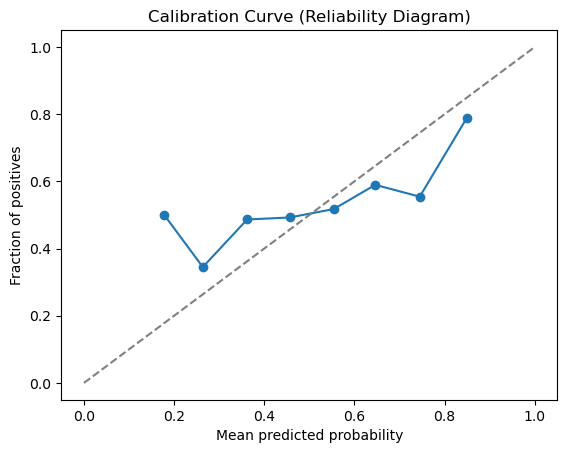

In [37]:
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve (Reliability Diagram)')
plt.show()

In [38]:
print(prob_pred, prob_true)

[0.178      0.26362069 0.36196911 0.45605664 0.55410256 0.64604478
 0.74467391 0.84947368] [0.5        0.34482759 0.48648649 0.49237473 0.51748252 0.58955224
 0.55434783 0.78947368]


In [41]:
cal_clf = CalibratedClassifierCV(estimator=clf, method='isotonic', cv='prefit')
cal_clf.fit(X_train, y_train)

y_pred_proba_cal = cal_clf.predict_proba(X_test)[:, 1]
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_pred_proba_cal, n_bins=8)
print(prob_pred_cal, prob_true_cal)

[0.01170939 0.20915033 0.32260062 0.44011339 0.55488175 0.67294118
 0.79447201 0.98293563] [0.47021944 0.52525253 0.47368421 0.45783133 0.55670103 0.57333333
 0.4939759  0.58962264]


/Users/bashaardhoot/miniforge3/lib/python3.10/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
